# ECG5000 - mLSTM Anomaly Detection

An mLSTM autoencoder trained only on class-1 (normal sinus rhythm) beats.
At test time the anomaly score is the per-sample mean reconstruction error.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import auc, roc_curve

from anomdet.data import load_dataset, make_loader
from anomdet.evaluate import compute_scores, evaluate
from anomdet.explain import plot_reconstruction
from anomdet.model import MLSTMAutoencoder
from anomdet.train import train

## Data

ECG5000 has 5 classes. Class `1` is the dominant normal rhythm; everything else is treated as anomalous.

In [2]:
X_train, y_train = load_dataset('ECG5000', split='train', normal_label='1')

n_normal = int((y_train == 0).sum())
n_anom   = int((y_train == 1).sum())
print(f'Shape: {X_train.shape}  (n, T, C)')
print(f'Normal: {n_normal}   Anomaly: {n_anom}')

Shape: torch.Size([500, 140, 1])  (n, T, C)
Normal: 292   Anomaly: 208


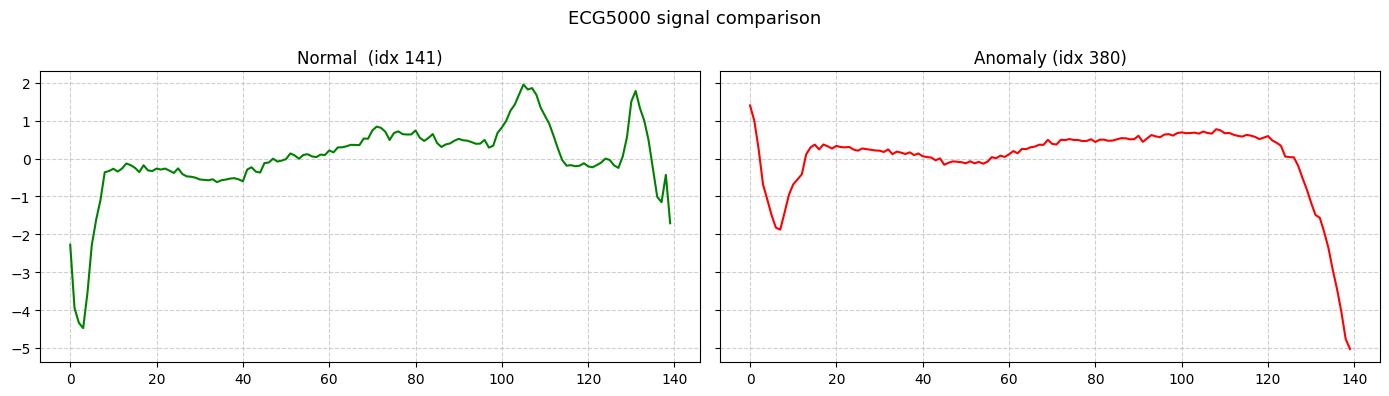

In [3]:
norm_idx = random.choice(np.where(y_train == 0)[0])
anom_idx = random.choice(np.where(y_train == 1)[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(X_train[norm_idx].squeeze(), color='green')
axes[0].set_title(f'Normal  (idx {norm_idx})')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(X_train[anom_idx].squeeze(), color='red')
axes[1].set_title(f'Anomaly (idx {anom_idx})')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('ECG5000 signal comparison', fontsize=13)
plt.tight_layout()
plt.show()

## Model

In [4]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

seq_len = X_train.shape[1]  # 140
in_dim  = X_train.shape[2]  # 1

model = MLSTMAutoencoder(
    seq_len=seq_len,
    in_dim=in_dim,
    d_model=64,
    latent_dim=16,
    enc_blocks=2,
    dec_blocks=2,
).to(device)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Device: cuda
Parameters: 123,057


## Training

AdamW + MSE loss + gradient clipping at 1.0. The loader filters to normal samples only.

In [5]:
loader = make_loader(X_train, y_train, batch_size=32, device=device)

loss_history = train(
    model, loader,
    epochs=500,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
)

Training: 100%|███████████████████████████████████████████████████| 500/500 [01:19<00:00,  6.26ep/s]


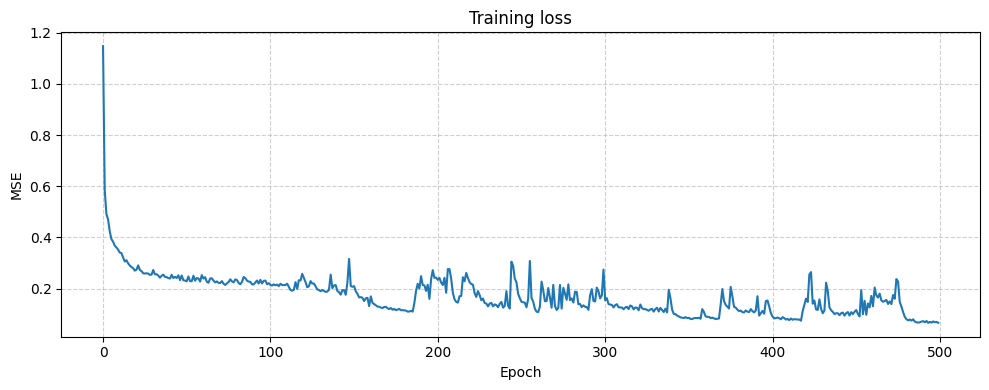

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=1.5, color='#1f77b4')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Evaluation

Anomaly score = mean per-sample MSE on the held-out test set.
Threshold is selected by maximising Youden's J (TPR - FPR) on the same split.

In [7]:
X_test, y_test = load_dataset('ECG5000', split='test', normal_label='1')

scores  = compute_scores(model, X_test, device)
metrics = evaluate(scores, y_test)

auroc  = metrics['auroc']
auprc  = metrics['auprc']
thresh = metrics['threshold']

print(f'AUROC:     {auroc:.4f}')
print(f'AUPRC:     {auprc:.4f}')
print(f'Threshold: {thresh:.6f}')

AUROC:     0.9828
AUPRC:     0.9710
Threshold: 0.259742


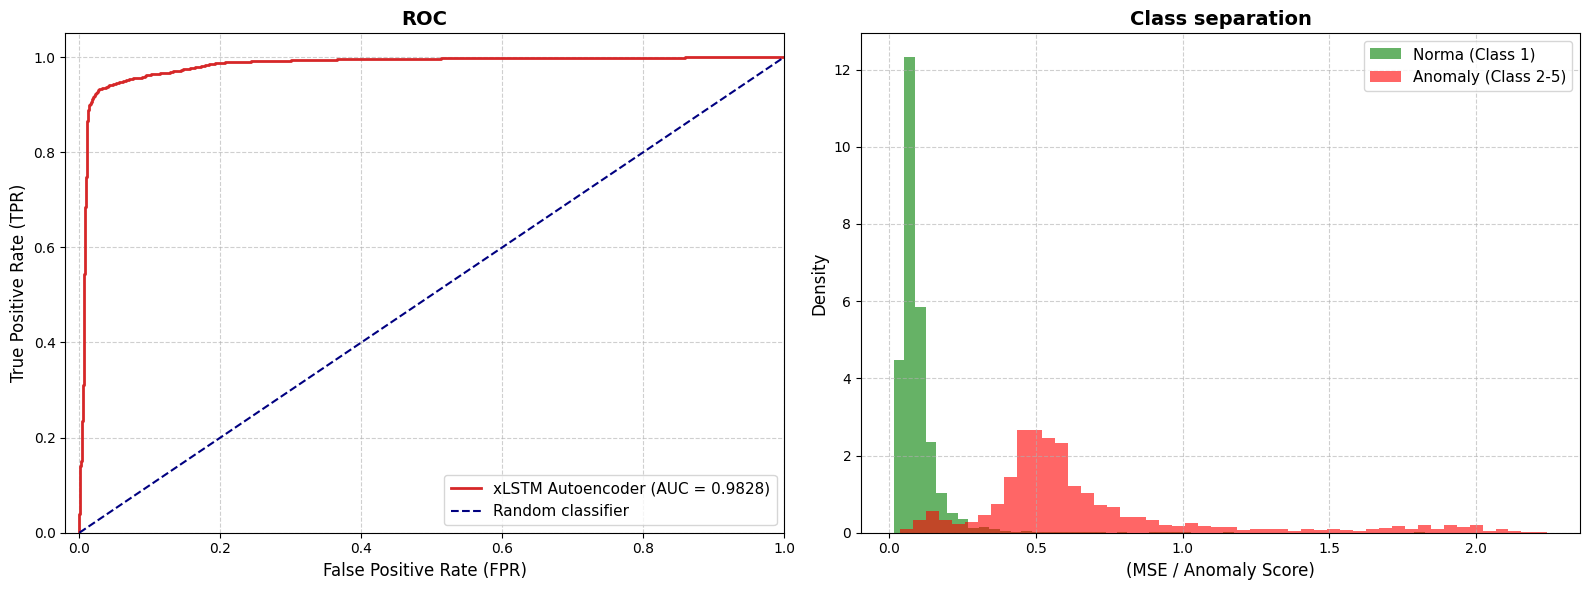

In [8]:
fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr, tpr, color='#d62728', lw=2, label=f'xLSTM Autoencoder (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'navy', linestyle='--', lw=1.5, label='Random classifier')
ax1.set_xlim([-0.02, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax1.set_title('ROC', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)

normal_scores = scores[y_test == 0]
anom_scores   = scores[y_test == 1]

ax2.hist(normal_scores, bins=50, alpha=0.6, color='green', density=True, label='Norma (Class 1)')
ax2.hist(anom_scores,   bins=50, alpha=0.6, color='red',   density=True, label='Anomaly (Class 2-5)')
ax2.set_xlabel('(MSE / Anomaly Score)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Class separation', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Error Map

Per-step MSE visualises where the model was surprised.
Orange shading marks the top 15% error region - the likely anomalous segment.

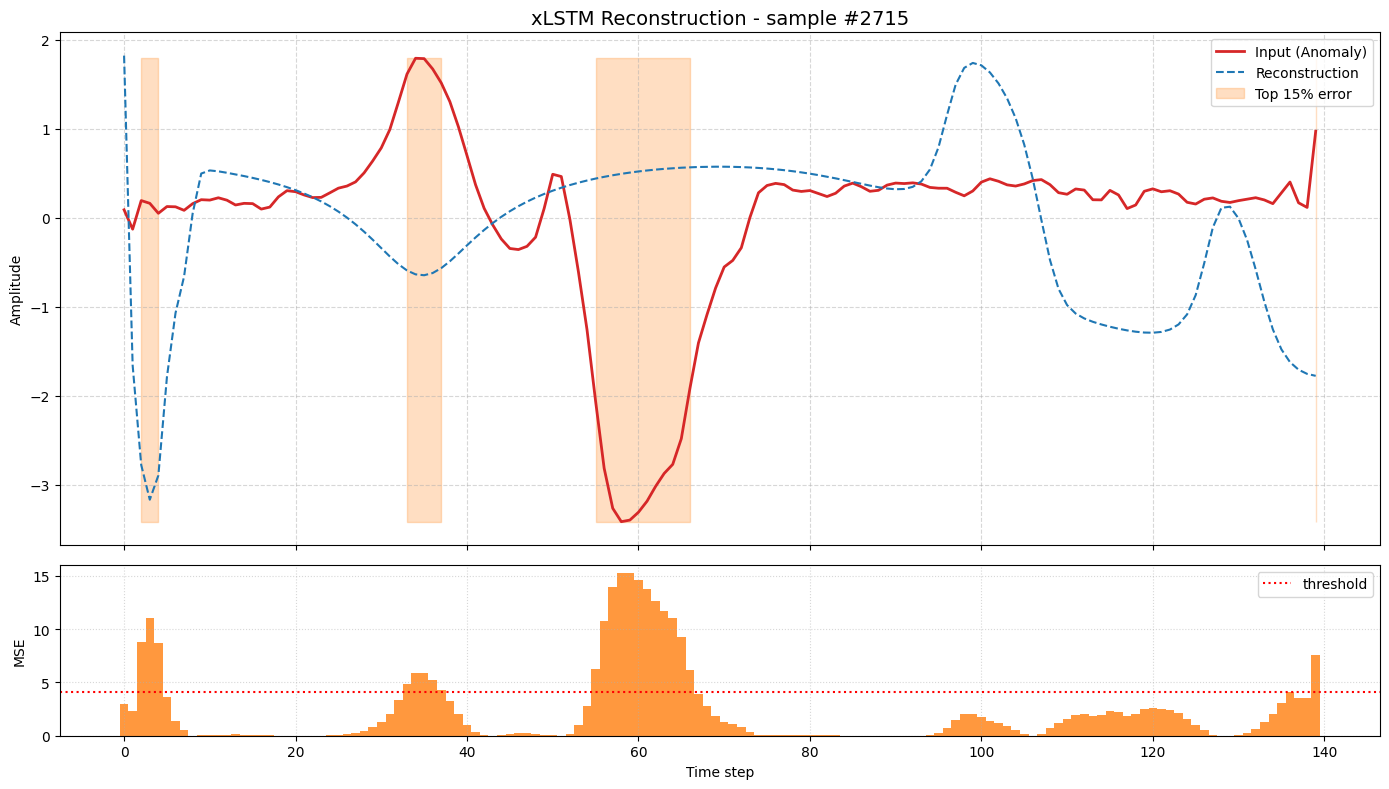

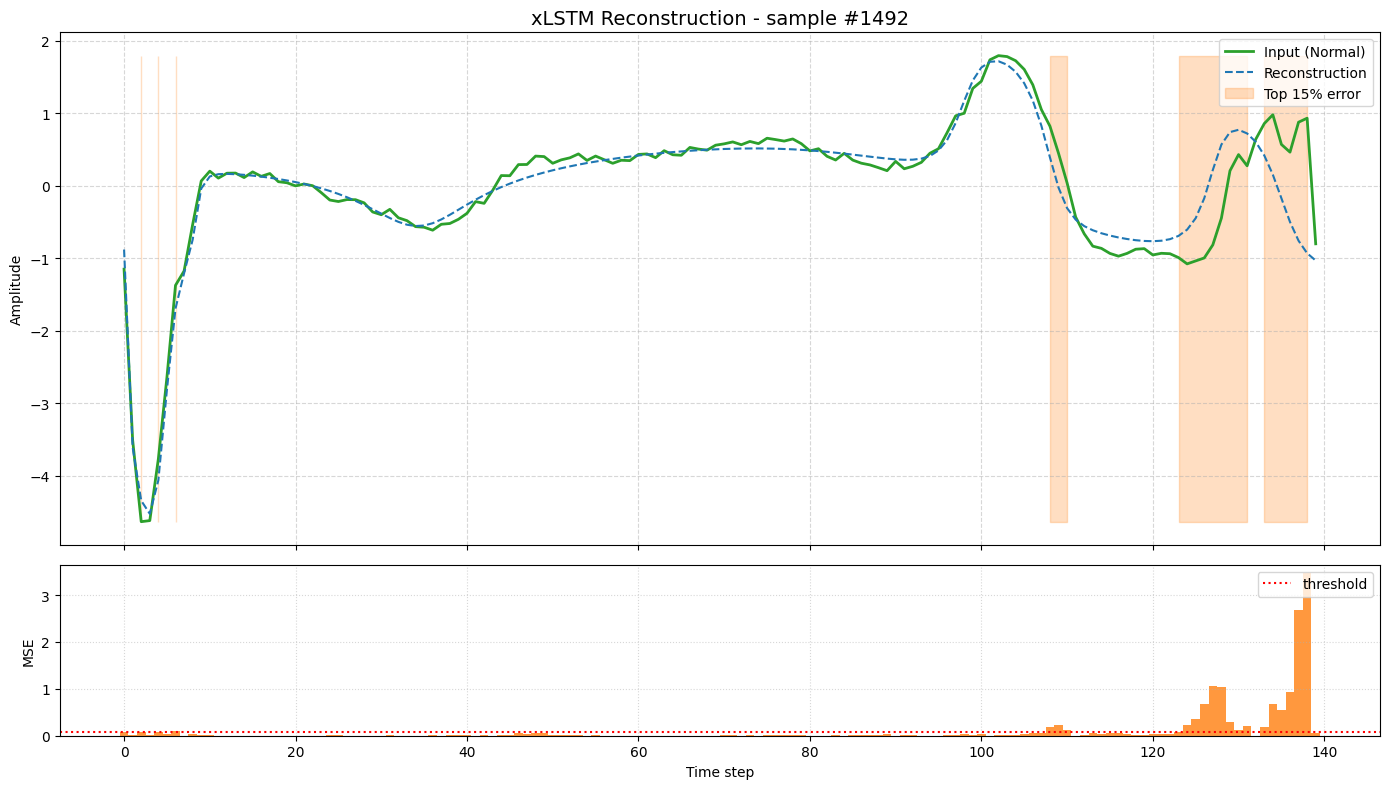

In [9]:
anom_indices = np.where(y_test == 1)[0]
norm_indices = np.where(y_test == 0)[0]

# highest-scoring anomaly vs a random normal
worst_anom = int(anom_indices[np.argmax(scores[anom_indices])])
rand_norm  = int(random.choice(norm_indices))

for idx in [worst_anom, rand_norm]:
    plot_reconstruction(model, X_test, y_test, index=idx, device=device)

## SHAP

KernelSHAP estimates which time steps push the anomaly score up (red) or down (blue).
Background = 50 normal samples; we explain the highest-scoring anomaly.

In [10]:
from anomdet.explain import shap_timeseries

# background: 50 normal samples, squeezed to (n, T)
background = X_test[y_test == 0][:50].squeeze(-1).numpy()

# explain the single worst anomaly
explain_sample = X_test[[worst_anom]].squeeze(-1).numpy()

shap_vals = shap_timeseries(model, background, explain_sample, device)

  0%|          | 0/1 [00:00<?, ?it/s]

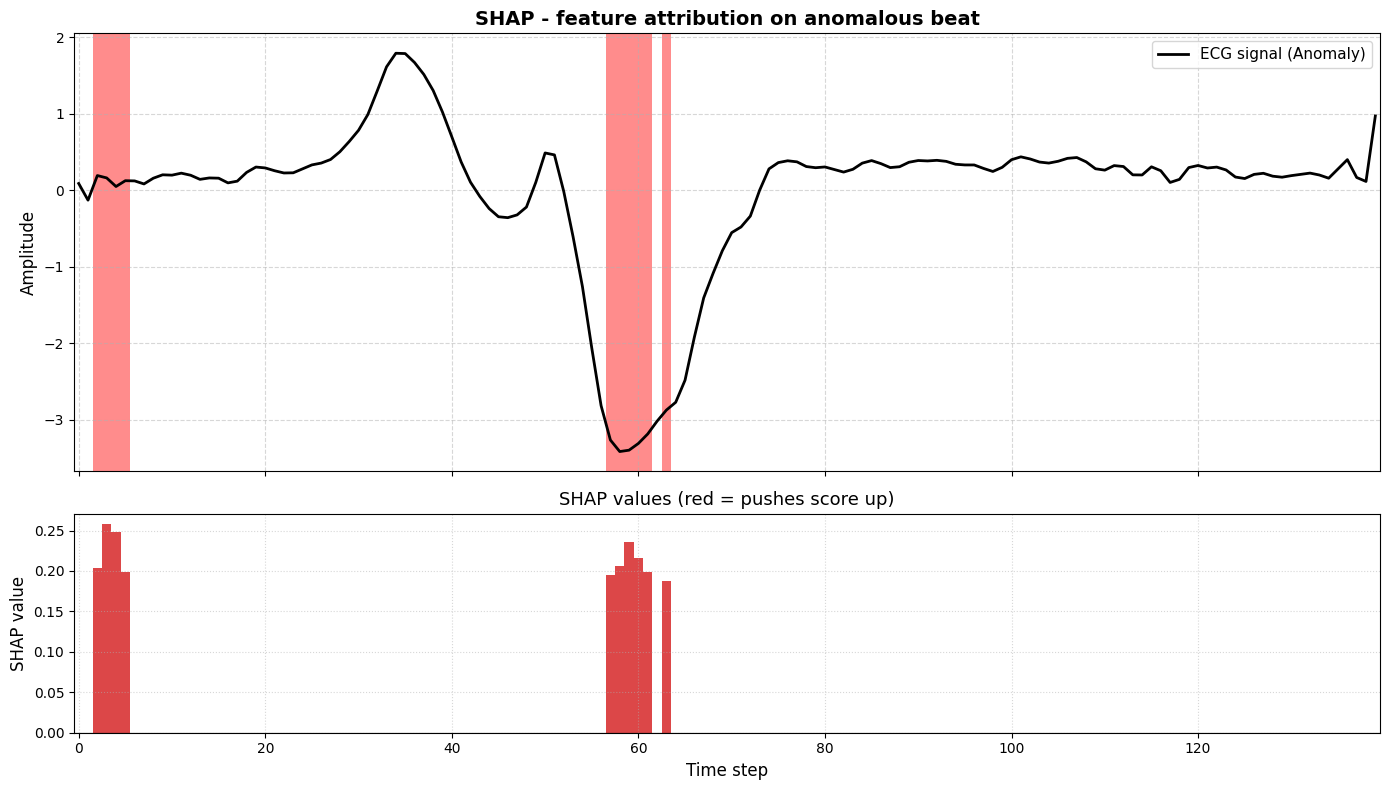

In [11]:
signal = explain_sample[0]   # (T,)
sv     = shap_vals[0]        # (T,)
time   = np.arange(len(signal))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(time, signal, color='black', linewidth=2, label='ECG signal (Anomaly)')
max_abs = np.abs(sv).max() + 1e-9
for t in time:
    color = 'red' if sv[t] > 0 else 'blue'
    ax1.axvspan(t - 0.5, t + 0.5, color=color, alpha=min(abs(sv[t]) / max_abs, 0.45), lw=0)
ax1.set_title('SHAP - feature attribution on anomalous beat', fontsize=14, fontweight='bold')
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

colors = ['#d62728' if v > 0 else '#1f77b4' for v in sv]
ax2.bar(time, sv, color=colors, width=1.0, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('SHAP values (red = pushes score up)', fontsize=13)
ax2.set_xlabel('Time step', fontsize=12)
ax2.set_ylabel('SHAP value', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.xlim(-0.5, len(signal) - 0.5)
plt.tight_layout()
plt.show()